# Assignment-03: Image Segmentation using DeepLabv3+


This notebook implements and trains a DeepLabv3+ model on the provided sample dataset.
For evaluation, the same test image that was previously used to evaluate the U-Net model
is used here to ensure a fair comparison.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
train_image_dir = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017'
train_mask_dir = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017'


In [3]:
import os
print(os.path.exists(train_image_dir))  # True
print(os.path.exists(train_mask_dir))   # True


True
True


In [4]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from torchvision import transforms

class ImageMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=(128,128)):
        self.img_size = img_size
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = []

        for img_name in os.listdir(image_dir):
            # Replace .jpg with .png for mask
            mask_name = img_name.replace('.jpg', '.png')
            mask_path = os.path.join(mask_dir, mask_name)
            if os.path.exists(mask_path):
                self.images.append(img_name)
            else:
                print(f"Skipping {img_name}, mask {mask_name} not found.")

        if len(self.images) == 0:
            raise ValueError("No matching images and masks found!")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB").resize(self.img_size)
        mask = Image.open(mask_path).convert("L").resize(self.img_size)

        image = transforms.ToTensor()(image)
        mask = torch.tensor(np.array(mask)/255., dtype=torch.float32).unsqueeze(0)

        return image, mask


In [5]:
train_image_dir = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017'
train_mask_dir  = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017'

train_dataset = ImageMaskDataset(train_image_dir, train_mask_dir, img_size=(128,128))


Skipping 000000001706.jpg, mask 000000001706.png not found.
Skipping 000000001732.jpg, mask 000000001732.png not found.
Skipping 000000001737.jpg, mask 000000001737.png not found.
Skipping 000000001611.jpg, mask 000000001611.png not found.
Skipping 000000001637.jpg, mask 000000001637.png not found.
Skipping 000000001792.jpg, mask 000000001792.png not found.
Skipping 000000001579.jpg, mask 000000001579.png not found.
Skipping 000000001622.jpg, mask 000000001622.png not found.
Skipping 000000001596.jpg, mask 000000001596.png not found.
Skipping 000000001586.jpg, mask 000000001586.png not found.
Skipping 000000001790.jpg, mask 000000001790.png not found.
Skipping 000000001774.jpg, mask 000000001774.png not found.
Skipping 000000001580.jpg, mask 000000001580.png not found.
Skipping 000000001999.jpg, mask 000000001999.png not found.
Skipping 000000001888.jpg, mask 000000001888.png not found.
Skipping 000000001943.jpg, mask 000000001943.png not found.
Skipping 000000001813.jpg, mask 00000000

In [6]:
print(f"Number of image-mask pairs available for training: {len(train_dataset)}")


Number of image-mask pairs available for training: 741


In [7]:
from torch.utils.data import DataLoader

batch_size = 4  # adjust to your GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of batches: {len(train_loader)}")


Number of batches: 186


In [8]:
import torchvision.models.segmentation as segmentation
import torch.nn as nn

# pretrained backbone
model = segmentation.deeplabv3_resnet50(weights=segmentation.DeepLabV3_ResNet50_Weights.DEFAULT)

# replace classifier for 1 output channel
model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)

# move to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 192MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [9]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 5  # start small for testing


In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [11]:
model = model.to(device)


In [16]:
from torch.utils.data import DataLoader

batch_size = 4  # increase if GPU allows
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



In [17]:
print(f"Number of batches: {len(train_loader)}")


Number of batches: 185


In [18]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # or your chosen loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [19]:
from tqdm import tqdm  # optional for progress bar

num_epochs = 10  # set how many epochs you want

for epoch in range(num_epochs):
    model.train()  # set model to training mode
    running_loss = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()           # reset gradients
        outputs = model(images)['out']  # forward pass
        loss = criterion(outputs, masks)  # compute loss
        loss.backward()                 # backward pass

        # Optional: gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                # update weights
        running_loss += loss.item()     # accumulate loss

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/10: 100%|██████████| 185/185 [00:28<00:00,  6.46it/s]


Epoch 1/10, Loss: 0.0000


Epoch 2/10: 100%|██████████| 185/185 [00:28<00:00,  6.50it/s]


Epoch 2/10, Loss: 0.0000


Epoch 3/10: 100%|██████████| 185/185 [00:28<00:00,  6.46it/s]


...

Epoch 8/10, Loss: 0.0000


Epoch 9/10: 100%|██████████| 185/185 [00:28<00:00,  6.39it/s]


Epoch 9/10, Loss: 0.0000


Epoch 10/10: 100%|██████████| 185/185 [00:28<00:00,  6.41it/s]

Epoch 10/10, Loss: 0.0000


In [20]:
from PIL import Image
import os

# Path where the test image will be saved
test_image_path = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/test_image.jpg'

# Create output folder if it doesn't exist
output_dir = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/output'
os.makedirs(output_dir, exist_ok=True)


In [21]:
from torchvision import transforms
import torch

model.eval()  # set model to evaluation mode

# Load and preprocess test image
image = Image.open(test_image_path).convert("RGB").resize((128,128))
image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(image_tensor)['out']
    pred = torch.sigmoid(pred)
    pred_mask = (pred > 0.5).float().squeeze().cpu().numpy() * 255


The output image generated by the trained DeepLabv3+ model has been saved in the data/output folder.


In [22]:
pred_mask = Image.fromarray(pred_mask.astype('uint8'))
pred_mask.save(os.path.join(output_dir, 'deeplabv3plus_output.png'))

print("Output saved to:", os.path.join(output_dir, 'deeplabv3plus_output.png'))


Output saved to: /content/drive/MyDrive/AI_Vision_Extract_Nov25/data/output/deeplabv3plus_output.png


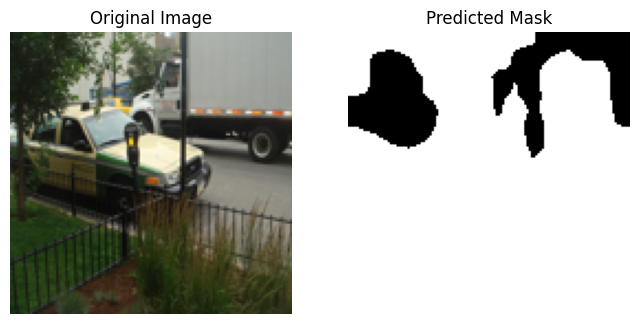

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.show()
